# 160 — Generate synchronized Phase-I video

This notebook synchronizes the USLaunchReport movie with BCHH infrasound, rotated Z/R/T seismic data, and Notebook 130 polarization attributes. The USLaunchReport movie has no independent absolute clock: `VIDEO_ANCHOR_MOVIE_S` is mapped to the authoritative infrasound-derived upper-stage source time in `config.SOURCE_EVENT_TIMES`.

Two display conventions are supported:

- `observed_utc`: receiver observations remain at their mapped arrival times;
- `source_aligned`: camera audio, BCHH infrasound, and the dominant ground-coupled seismic motion are shifted earlier by their physical acoustic travel times so they align approximately with the video/source chronology.

Source-to-BCHH propagation uses the Notebook 020 meteorological effective speed (approximately 351 m s⁻¹). Camera audio uses the same weather state projected along the source-to-camera azimuth (approximately 349 m s⁻¹). The approximately 352 m s⁻¹ Notebook 080 result is the empirical trace velocity across the small infrasound array and is recorded for comparison only; it is not used as a source-to-receiver propagation speed.

This remains the animated-movie producer; 165 makes a separate static figure. The saved configuration invalidates frames when upstream data or rendering controls change. Acoustic reduction of seismic/polarization panels is a display assumption for the airwave, not a seismic-phase identification.

Deferred enhancement: add a spectrogram with a scrolling time marker and a source/camera/BCHH map beside the main video panel.


## 1. Imports, project paths, and required products


In [1]:
from __future__ import annotations

import json
import hashlib
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from obspy import Stream, UTCDateTime, read
from pyproj import Geod

try:
    from scipy.io import wavfile
except ImportError:
    wavfile = None

try:
    import av
except ImportError as exc:
    raise ImportError(
        "Notebook 160 uses PyAV for timestamp-aware video reading. Install it "
        "in this kernel with `python -m pip install av`."
    ) from exc

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config
from modules.kml_utils import read_kml_points

ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
POLARIZATION_ROOT = config.NB130_DIR
POLARIZATION_CSV = POLARIZATION_ROOT / "polarization_timeseries.csv"
ROTATED_ZRT_PICKLE = POLARIZATION_ROOT / "seismic_zrt.pkl"

for label, path in {
    "Notebook 010 analysis configuration": ANALYSIS_CONFIG_FILE,
    "Notebook 020 weather/acoustic summary": WEATHER_SUMMARY_FILE,
    "Notebook 130 polarization CSV": POLARIZATION_CSV,
    "Notebook 130 rotated ZRT Stream": ROTATED_ZRT_PICKLE,
    "launchpad/camera KML": config.KML_FILE,
}.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE).iloc[0]

BASELINE_STREAM_FILE = (
    config.NB010_DIR
    / "bchh_corrected_moving_median_baseline_removed.pkl"
)
if not BASELINE_STREAM_FILE.exists():
    raise FileNotFoundError(BASELINE_STREAM_FILE)

if config.USLAUNCHREPORT_VIDEO_FILE is None:
    raise RuntimeError(
        "Set FALCON9_USLAUNCHREPORT_VIDEO_FILE to a locally obtained "
        "copy of the USLaunchReport source video."
    )
VIDEO_FILE = config.USLAUNCHREPORT_VIDEO_FILE
if not VIDEO_FILE.exists():
    raise FileNotFoundError(
        "USLaunchReport movie not found at the path specified by "
        "FALCON9_USLAUNCHREPORT_VIDEO_FILE:\n"
        f"{VIDEO_FILE}"
    )

OUTPUT_ROOT = config.NB160_DIR
SYNC_CONFIG_JSON = OUTPUT_ROOT / "video_sync_configuration.json"
CALIBRATION_FIGURE = OUTPUT_ROOT / "video_sync_anchor_preview.pdf"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Video:", VIDEO_FILE)
print("Waveforms:", BASELINE_STREAM_FILE)
print("Polarization:", POLARIZATION_CSV)
print("Weather:", WEATHER_SUMMARY_FILE)

def file_fingerprint(path):
    path = Path(path)
    stat = path.stat()
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return {"sha256": digest.hexdigest(), "size_bytes": stat.st_size}

def write_review_json(path, value):
    """Preserve the previous manual product before replacing it."""
    path = Path(path)
    if path.exists():
        from datetime import datetime, timezone
        import shutil
        stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
        shutil.copy2(path, path.with_name(path.stem + ".backup_" + stamp + path.suffix))
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")
    temporary.replace(path)


Video: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/SpaceX - Static Fire Anomaly - AMOS-6 - 09-01-2016.mov
Waveforms: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
Polarization: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/130_analyze_seismic_polarization/polarization_timeseries.csv
Weather: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/020_analyze_ksc_weather/weather_acoustic_summary.csv


## 2. Synchronization and rendering controls


In [2]:
# -------------------------------------------------------------------------
# Synchronization, propagation, audio, and render parameters
# -------------------------------------------------------------------------
required_source_keys = (
    "upper_stage",
    "lower_stage",
    "payload_impact",
    "payload_explosion",
)
missing_source_keys = [
    key for key in required_source_keys
    if key not in config.SOURCE_EVENT_TIMES
]
if missing_source_keys:
    raise KeyError(
        "SOURCE_EVENT_TIMES lacks required events: "
        + ", ".join(missing_source_keys)
    )

EVENT_024_EVENT_KEY = next(
    (
        key for key in ("event_024",)
        if key in config.SOURCE_EVENT_TIMES
    ),
    None,
)
if EVENT_024_EVENT_KEY is None:
    raise KeyError(
        "SOURCE_EVENT_TIMES must contain 'event_024'"
    )

UPPER_STAGE_SOURCE_UTC = UTCDateTime(config.SOURCE_EVENT_TIMES["upper_stage"])
LOWER_STAGE_SOURCE_UTC = UTCDateTime(config.SOURCE_EVENT_TIMES["lower_stage"])
PAYLOAD_IMPACT_SOURCE_UTC = UTCDateTime(
    config.SOURCE_EVENT_TIMES["payload_impact"]
)
PAYLOAD_EXPLOSION_SOURCE_UTC = UTCDateTime(
    config.SOURCE_EVENT_TIMES["payload_explosion"]
)
EVENT_024_SOURCE_UTC = UTCDateTime(
    config.SOURCE_EVENT_TIMES[EVENT_024_EVENT_KEY]
)

# Compatibility aliases retained for helper functions written in earlier drafts.
SECOND_STAGE_SOURCE_UTC = UPPER_STAGE_SOURCE_UTC
MAIN_EXPLOSION_SOURCE_UTC = LOWER_STAGE_SOURCE_UTC
PAYLOAD_SOURCE_UTC = PAYLOAD_IMPACT_SOURCE_UTC

NAMED_SOURCE_EVENTS = [
    ("upper_stage", "Upper-stage failure", UPPER_STAGE_SOURCE_UTC),
    ("lower_stage", "Principal explosion", LOWER_STAGE_SOURCE_UTC),
    ("payload_impact", "Payload impact", PAYLOAD_IMPACT_SOURCE_UTC),
    ("payload_explosion", "Payload explosion", PAYLOAD_EXPLOSION_SOURCE_UTC),
    (EVENT_024_EVENT_KEY, "Event 024", EVENT_024_SOURCE_UTC),
]

# The movie has no absolute timestamp. This mapping is a constructed alignment:
# the first upper-stage flash at VIDEO_ANCHOR_S is assigned the infrasound-derived
# upper-stage source time stored in the shared configuration.
VIDEO_ANCHOR_UTC = UTCDateTime(config.VIDEO_ANCHOR_UTC)
VIDEO_ANCHOR_S = float(config.VIDEO_ANCHOR_MOVIE_S)
ANCHOR_IS_CONFIRMED = True

if abs(float(VIDEO_ANCHOR_UTC - UPPER_STAGE_SOURCE_UTC)) > 1e-6:
    raise ValueError(
        "VIDEO_ANCHOR_UTC must equal SOURCE_EVENT_TIMES['upper_stage'] in the "
        "current constructed movie-time mapping."
    )

# Default production mode: align video, camera audio, infrasound, and the
# dominant ground-coupled seismic airwave in approximate source time.
ALIGNMENT_MODE = "source_aligned"
VALID_ALIGNMENT_MODES = {"observed_utc", "source_aligned"}
if ALIGNMENT_MODE not in VALID_ALIGNMENT_MODES:
    raise ValueError(
        f"ALIGNMENT_MODE must be one of {sorted(VALID_ALIGNMENT_MODES)}"
    )

# Mode-specific paths prevent observed-time and source-aligned frames/audio from
# being accidentally mixed. The JSON handoff always describes the latest run.
FRAME_DIR = OUTPUT_ROOT / f"frames_phase1_{ALIGNMENT_MODE}"
OUTPUT_MOVIE = (
    OUTPUT_ROOT
    / f"youtube_waveform_polarization_{ALIGNMENT_MODE}.mp4"
)
EXTRACTED_AUDIO_WAV = (
    OUTPUT_ROOT / f"youtube_audio_{ALIGNMENT_MODE}.wav"
)
CAMERA_PROPAGATION_AUDIT_CSV = (
    OUTPUT_ROOT / "youtube_camera_propagation.csv"
)
FRAME_MANIFEST_JSON = FRAME_DIR / "render_configuration.json"
FRAME_DIR.mkdir(parents=True, exist_ok=True)

SHOW_CAMERA_ACOUSTIC_CURSOR = True

# -------------------------------------------------------------------------
# Meteorological propagation
# -------------------------------------------------------------------------
# Notebook 020 predicts source-to-BCHH propagation from temperature, humidity,
# and the wind component along SLC-40 -> BCHH.
SOUND_SPEED_MPS = float(weather_summary["effective_sound_speed_mps"])
STILL_AIR_SOUND_SPEED_MPS = float(
    weather_summary["still_air_sound_speed_mps"]
)
PATH_MEAN_WIND_SPEED_MPS = float(
    weather_summary["path_vector_mean_wind_speed_mps"]
)
PATH_MEAN_WIND_FROM_DEG = float(
    weather_summary["path_vector_mean_wind_direction_from_deg"]
)
PATH_MEAN_WIND_TO_DEG = (PATH_MEAN_WIND_FROM_DEG + 180.0) % 360.0
EMPIRICAL_ARRAY_TRACE_SPEED_MPS = 352.0

if not 300.0 <= SOUND_SPEED_MPS <= 380.0:
    raise ValueError(f"Implausible BCHH effective sound speed: {SOUND_SPEED_MPS}")

# Read both source and camera coordinates from the repository KML.
kml_points = read_kml_points(config.KML_FILE)
for required_point in ("SLC40", "YouTube Video"):
    if required_point not in kml_points:
        raise KeyError(
            f"{required_point!r} is absent from {config.KML_FILE}; "
            f"available={sorted(kml_points)}"
        )
source_point = kml_points["SLC40"]
camera_point = kml_points["YouTube Video"]
SLC40_LATITUDE = float(source_point["lat"])
SLC40_LONGITUDE = float(source_point["lon"])
YOUTUBE_CAMERA_LATITUDE = float(camera_point["lat"])
YOUTUBE_CAMERA_LONGITUDE = float(camera_point["lon"])

geod = Geod(ellps="WGS84")
YOUTUBE_CAMERA_RAY_AZIMUTH_DEG, _, YOUTUBE_CAMERA_DISTANCE_M = geod.inv(
    SLC40_LONGITUDE,
    SLC40_LATITUDE,
    YOUTUBE_CAMERA_LONGITUDE,
    YOUTUBE_CAMERA_LATITUDE,
)
YOUTUBE_CAMERA_RAY_AZIMUTH_DEG %= 360.0
YOUTUBE_CAMERA_WIND_ALONG_RAY_MPS = (
    PATH_MEAN_WIND_SPEED_MPS
    * np.cos(
        np.deg2rad(
            YOUTUBE_CAMERA_RAY_AZIMUTH_DEG - PATH_MEAN_WIND_TO_DEG
        )
    )
)
YOUTUBE_CAMERA_EFFECTIVE_SPEED_MPS = (
    STILL_AIR_SOUND_SPEED_MPS + YOUTUBE_CAMERA_WIND_ALONG_RAY_MPS
)
YOUTUBE_CAMERA_TRAVEL_TIME_S = (
    YOUTUBE_CAMERA_DISTANCE_M / YOUTUBE_CAMERA_EFFECTIVE_SPEED_MPS
)

if not 300.0 <= YOUTUBE_CAMERA_EFFECTIVE_SPEED_MPS <= 380.0:
    raise ValueError(
        "Implausible camera-path effective sound speed: "
        f"{YOUTUBE_CAMERA_EFFECTIVE_SPEED_MPS}"
    )

youtube_camera = {
    "camera_id": "youtube",
    "name": "USLaunchReport/YouTube Video",
    "latitude": YOUTUBE_CAMERA_LATITUDE,
    "longitude": YOUTUBE_CAMERA_LONGITUDE,
    "distance_m": float(YOUTUBE_CAMERA_DISTANCE_M),
    "ray_azimuth_deg": float(YOUTUBE_CAMERA_RAY_AZIMUTH_DEG),
    "still_air_sound_speed_mps": STILL_AIR_SOUND_SPEED_MPS,
    "wind_speed_mps": PATH_MEAN_WIND_SPEED_MPS,
    "wind_direction_from_deg": PATH_MEAN_WIND_FROM_DEG,
    "wind_along_ray_mps": float(YOUTUBE_CAMERA_WIND_ALONG_RAY_MPS),
    "effective_speed_mps": float(YOUTUBE_CAMERA_EFFECTIVE_SPEED_MPS),
    "travel_time_s": float(YOUTUBE_CAMERA_TRAVEL_TIME_S),
    "source": "Notebook 020 weather projected along SLC-40-to-camera azimuth",
    "used_fallback": False,
}
pd.DataFrame([youtube_camera]).to_csv(
    CAMERA_PROPAGATION_AUDIT_CSV,
    index=False,
)

# Exploratory pre-airwave seismic onset from Notebook 140. It is not
# identified as a P wave and is disabled in the production video.
CANDIDATE_P_DELAY_S = 1.85
BCHH_REFERENCE_DISTANCE_M = float(
    analysis_config["array_reference"]["distance_m"]
)
P_WAVE_SPEED_MPS = BCHH_REFERENCE_DISTANCE_M / CANDIDATE_P_DELAY_S
CANDIDATE_P_EVENT_KEYS = set()

# Calibration-search controls.
ANCHOR_SEARCH_START_S = 67.0
ANCHOR_SEARCH_END_S = 85.0
ANCHOR_SEARCH_STEP_S = 1.0
FINE_ANCHOR_HALF_WIDTH_S = 0.75

RENDER_FPS = float(config.VIDEO_NOMINAL_FPS)
RENDER_START_UTC = UPPER_STAGE_SOURCE_UTC - 2.0
RENDER_END_UTC = EVENT_024_SOURCE_UTC + 4.0
WAVEFORM_ZOOM_S = 6.0
FIGURE_DPI = 100

SEISMIC_FILTER_HZ = (0.5, 20.0)
INFRASOUND_FILTER_HZ = (0.5, 20.0)

SHOW_CURRENT_VIDEO_UTC_CURSOR = True
SHOW_DYNAMIC_INFRASOUND_ARRIVALS = True
SHOW_DYNAMIC_P_ARRIVALS = False
SHOW_STATIC_EVENT_MARKERS = True

# Camera audio is extracted in native movie timing in observed mode and advanced
# by its meteorological travel time in source-aligned mode.
INCLUDE_VIDEO_AUDIO_IN_MP4 = True
SHOW_VIDEO_AUDIO_PANEL = True
EXTRACT_AUDIO_FOR_PANEL = True
AUDIO_DISPLAY_SAMPLE_RATE_HZ = 12000
AUDIO_PANEL_HIGHPASS_HZ = 300.0
AUDIO_PANEL_ZOOMED = False

# Derived-frame controls.
#
# IMPORTANT: existing PNG frames are deleted ONLY when DELETE_EXISTING_FRAMES
# is explicitly True. A manifest/configuration difference is reported but never
# silently destroys an interrupted render.
RENDER_PNG_FRAMES = True
ASSEMBLE_MP4 = True
DELETE_EXISTING_FRAMES = False
MAX_FRAMES = None

# Manual schema/version tag for the rendered-frame appearance. Increment this
# only when a code change intentionally makes existing frames incompatible.
RENDER_SCHEMA_VERSION = 2

# Long renders are processed in small batches. Between batches the PyAV reader
# is reopened and Matplotlib/Python resources are collected. This prevents the
# severe progressive slowdown/kernel instability seen in long 600+ frame runs.
RENDER_BATCH_SIZE = 40
REOPEN_VIDEO_READER_BETWEEN_BATCHES = True


def delay_from_anchor(utc_time: UTCDateTime) -> float:
    return float(utc_time - VIDEO_ANCHOR_UTC)


video_start_utc = VIDEO_ANCHOR_UTC - VIDEO_ANCHOR_S
render_duration_s = float(RENDER_END_UTC - RENDER_START_UTC)
render_start_video_s = VIDEO_ANCHOR_S + float(
    RENDER_START_UTC - VIDEO_ANCHOR_UTC
)

print("Configured movie anchor:", VIDEO_ANCHOR_S, "s <->", VIDEO_ANCHOR_UTC)
print("Movie frame-zero mapped UTC:", video_start_utc)
print("Alignment mode:", ALIGNMENT_MODE)
print("Render interval:", RENDER_START_UTC, "to", RENDER_END_UTC)
print("Output movie:", OUTPUT_MOVIE)
print(
    "BCHH meteorological effective speed:",
    f"{SOUND_SPEED_MPS:.3f} m/s",
)
print(
    "Empirical array trace speed (comparison only):",
    f"{EMPIRICAL_ARRAY_TRACE_SPEED_MPS:.3f} m/s",
)
print(
    "YouTube-camera meteorological propagation:",
    f"distance={YOUTUBE_CAMERA_DISTANCE_M:.2f} m; "
    f"speed={YOUTUBE_CAMERA_EFFECTIVE_SPEED_MPS:.3f} m/s; "
    f"travel={YOUTUBE_CAMERA_TRAVEL_TIME_S:.3f} s",
)
print(
    "Exploratory pre-airwave apparent speed (markers disabled):",
    f"{P_WAVE_SPEED_MPS:.1f} m/s from "
    f"{BCHH_REFERENCE_DISTANCE_M:.1f} m / {CANDIDATE_P_DELAY_S:.2f} s",
)


Configured movie anchor: 71.72136666666667 s <-> 2016-09-01T13:07:11.913000Z
Movie frame-zero mapped UTC: 2016-09-01T13:06:00.191633Z
Alignment mode: source_aligned
Render interval: 2016-09-01T13:07:09.913000Z to 2016-09-01T13:07:30.458000Z
Output movie: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/youtube_waveform_polarization_source_aligned.mp4
BCHH meteorological effective speed: 350.977 m/s
Empirical array trace speed (comparison only): 352.000 m/s
YouTube-camera meteorological propagation: distance=4254.53 m; speed=349.802 m/s; travel=12.163 s
Exploratory pre-airwave apparent speed (markers disabled): 767.5 m/s from 1419.9 m / 1.85 s


## 3. Load and prepare waveforms and polarization


In [3]:
st_all = read(str(BASELINE_STREAM_FILE), format="PICKLE")
st_zrt = read(str(ROTATED_ZRT_PICKLE), format="PICKLE")
polarization = pd.read_csv(POLARIZATION_CSV)

pressure_channels = tuple(
    str(channel).upper() for channel in analysis_config["pressure_channels"]
)
st_infrasound = Stream(
    trace.copy() for trace in st_all
    if trace.stats.channel.upper() in pressure_channels
)

for trace in list(st_infrasound) + list(st_zrt):
    if np.ma.isMaskedArray(trace.data) or not np.isfinite(trace.data).all():
        raise ValueError(f"{trace.id}: missing/nonfinite samples")
if len(st_infrasound) != len(pressure_channels):
    raise ValueError("Expected one trace per pressure channel")
st_seismic_plot = st_zrt.copy()
st_seismic_plot.detrend("linear")
st_seismic_plot.detrend("demean")
st_seismic_plot.taper(max_percentage=0.02, type="cosine")
st_seismic_plot.filter(
    "bandpass",
    freqmin=SEISMIC_FILTER_HZ[0],
    freqmax=SEISMIC_FILTER_HZ[1],
    corners=4,
    zerophase=True,
)

st_infrasound_plot = st_infrasound.copy()
st_infrasound_plot.detrend("linear")
st_infrasound_plot.detrend("demean")
st_infrasound_plot.taper(max_percentage=0.02, type="cosine")
st_infrasound_plot.filter(
    "bandpass",
    freqmin=INFRASOUND_FILTER_HZ[0],
    freqmax=INFRASOUND_FILTER_HZ[1],
    corners=4,
    zerophase=True,
)


def robust_scale(values: np.ndarray, percentile: float = 99.5) -> float:
    scale = np.nanpercentile(np.abs(np.asarray(values, dtype=float)), percentile)
    return float(scale) if np.isfinite(scale) and scale > 0 else 1.0


def relative_time(trace, reference_utc: UTCDateTime) -> np.ndarray:
    return trace.times(reftime=reference_utc)


def receiver_time_shift_s(kind: str, trace=None) -> float:
    """Amount subtracted from receiver time to obtain displayed source time."""
    if ALIGNMENT_MODE == "observed_utc":
        return 0.0
    if kind == "camera_audio":
        return YOUTUBE_CAMERA_TRAVEL_TIME_S
    if kind == "infrasound":
        if trace is None:
            return infra_reference_delay_s - config.REDUCED_TIME_RESIDUAL_SHIFT_S
        return (
            trace_source_distance_m(trace) / SOUND_SPEED_MPS
            - config.REDUCED_TIME_RESIDUAL_SHIFT_S
        )
    if kind in {"seismic", "polarization"}:
        # The displayed Z/R/T motion and its polarization are dominated by
        # the ground-coupled airwave, so source-aligned mode removes the
        # acoustic travel time. Exploratory pre-airwave markers are not
        # used to define the display clock.
        if trace is None:
            return (
                seismic_reference_distance_m / SOUND_SPEED_MPS
                - config.REDUCED_TIME_RESIDUAL_SHIFT_S
            )
        return (
            trace_source_distance_m(trace) / SOUND_SPEED_MPS
            - config.REDUCED_TIME_RESIDUAL_SHIFT_S
        )
    raise ValueError(f"Unknown receiver kind: {kind}")


seismic_scales = {trace.id: robust_scale(trace.data) for trace in st_seismic_plot}
infra_scales = {trace.id: robust_scale(trace.data) for trace in st_infrasound_plot}

# -------------------------------------------------------------------------
# Normalize Notebook 130's time axis.
# -------------------------------------------------------------------------
# Corrected Notebook 130 products use Unix epoch seconds (~1.47e9 in 2016).
# Older products used Matplotlib serial days (~17045). Detect and repair those
# files automatically so the polarization panel cannot silently be blank.
polarization["time_epoch_s"] = pd.to_numeric(
    polarization["time_epoch_s"], errors="coerce"
)
finite_times = polarization["time_epoch_s"].dropna().to_numpy(dtype=float)
if finite_times.size == 0:
    raise ValueError(f"No finite time_epoch_s values in {POLARIZATION_CSV}")

median_time_value = float(np.nanmedian(finite_times))
if 10_000.0 < median_time_value < 100_000.0:
    import matplotlib.dates as mdates
    repaired_datetimes = mdates.num2date(
        polarization["time_epoch_s"].to_numpy(dtype=float),
        tz=None,
    )
    polarization["time_epoch_s"] = np.array(
        [UTCDateTime(value).timestamp for value in repaired_datetimes],
        dtype=float,
    )
    print(
        "Repaired legacy polarization time axis: Matplotlib serial days -> "
        "Unix epoch seconds. Rerun Notebook 130 when convenient."
    )
elif median_time_value < 100_000_000.0:
    raise ValueError(
        "Unrecognized polarization time axis: median time_epoch_s="
        f"{median_time_value}. Expected Unix epoch seconds or Matplotlib days."
    )

# Coerce every plotted attribute to numeric and report usable values.
POLARIZATION_ATTRIBUTES = [
    ("linearity", "Linearity"),
    ("rectilinearity", "Rectilinearity"),
    ("planarity", "Planarity"),
    ("ellipticity", "Ellipticity"),
    ("degree_of_polarization", "DOP"),
]
for column, _ in POLARIZATION_ATTRIBUTES:
    if column in polarization.columns:
        polarization[column] = pd.to_numeric(polarization[column], errors="coerce")

upper_stage_epoch_s = float(UPPER_STAGE_SOURCE_UTC.timestamp)
polarization["elapsed_from_upper_stage_s"] = (
    polarization["time_epoch_s"] - upper_stage_epoch_s
)
# Legacy alias retained for older plotting code.
polarization["elapsed_from_explosion_s"] = (
    polarization["elapsed_from_upper_stage_s"]
)
polarization = polarization.sort_values("elapsed_from_upper_stage_s").reset_index(drop=True)

available_pol_start = float(polarization["elapsed_from_explosion_s"].min())
available_pol_end = float(polarization["elapsed_from_explosion_s"].max())
render_start_s = float(RENDER_START_UTC - VIDEO_ANCHOR_UTC)
render_end_s = float(RENDER_END_UTC - VIDEO_ANCHOR_UTC)
if available_pol_end < render_start_s or available_pol_start > render_end_s:
    raise ValueError(
        "Polarization data do not overlap the render interval:\n"
        f"  polarization: {available_pol_start:.3f} to {available_pol_end:.3f} s\n"
        f"  rendering:    {render_start_s:.3f} to {render_end_s:.3f} s"
    )

print(st_seismic_plot)
print(st_infrasound_plot)
print(
    "Polarization elapsed-time range:",
    f"{available_pol_start:.3f} to {available_pol_end:.3f} s"
)
for column, label in POLARIZATION_ATTRIBUTES:
    if column in polarization.columns:
        print(f"  {label}: {polarization[column].notna().sum()} finite values")
display(polarization.head())


# -------------------------------------------------------------------------
# Exact per-trace source geometry preserved by Notebooks 01/02
# -------------------------------------------------------------------------
def trace_source_distance_m(trace) -> float:
    """
    Return the exact SLC-40 source-to-sensor distance stored on the Trace.

    stats.source_geometry.distance_m is authoritative. The duplicate value in
    stats.channel_processing_summary is checked for consistency when present.
    No nominal-distance fallback is permitted.
    """
    geometry = getattr(trace.stats, "source_geometry", None)
    if geometry is None:
        raise ValueError(f"{trace.id} has no stats.source_geometry metadata.")

    try:
        distance_m = float(geometry.distance_m)
    except (AttributeError, TypeError, ValueError) as exc:
        raise ValueError(
            f"{trace.id} has no valid stats.source_geometry.distance_m."
        ) from exc

    if not np.isfinite(distance_m) or distance_m <= 0.0:
        raise ValueError(
            f"{trace.id} has invalid source distance: {distance_m!r}"
        )

    summary = getattr(trace.stats, "channel_processing_summary", None)
    if summary is not None:
        summary_distance = getattr(
            summary,
            "source_to_sensor_distance_m",
            None,
        )
        if summary_distance is not None:
            summary_distance = float(summary_distance)
            if not np.isclose(
                distance_m,
                summary_distance,
                rtol=0.0,
                atol=1e-6,
            ):
                raise ValueError(
                    f"Inconsistent source distances for {trace.id}: "
                    f"source_geometry={distance_m:.6f} m; "
                    f"channel_processing_summary={summary_distance:.6f} m"
                )

    return distance_m


def trace_geometry_row(trace) -> dict:
    geometry = trace.stats.source_geometry
    coordinates = trace.stats.coordinates
    return {
        "trace_id": trace.id,
        "channel": str(trace.stats.channel),
        "sensor_latitude": float(coordinates.latitude),
        "sensor_longitude": float(coordinates.longitude),
        "sensor_elevation_m": float(coordinates.elevation_m),
        "source_name": str(geometry.source_name),
        "source_latitude": float(geometry.source_latitude),
        "source_longitude": float(geometry.source_longitude),
        "source_elevation_m": float(geometry.source_elevation_m),
        "distance_m": trace_source_distance_m(trace),
        "source_to_sensor_azimuth_deg": float(
            geometry.source_to_sensor_azimuth_deg
        ),
        "sensor_to_source_back_azimuth_deg": float(
            geometry.sensor_to_source_back_azimuth_deg
        ),
    }


trace_geometry = pd.DataFrame(
    [
        trace_geometry_row(trace)
        for trace in list(st_infrasound_plot) + list(st_seismic_plot)
    ]
)

if trace_geometry["trace_id"].duplicated().any():
    duplicates = trace_geometry.loc[
        trace_geometry["trace_id"].duplicated(keep=False),
        "trace_id",
    ].tolist()
    raise ValueError(f"Duplicate trace IDs in geometry table: {duplicates}")

infra_distances_m = {
    trace.id: trace_source_distance_m(trace)
    for trace in st_infrasound_plot
}
seismic_distances_m = {
    trace.id: trace_source_distance_m(trace)
    for trace in st_seismic_plot
}

# Exact array-wide acoustic arrival interval from the three infrasound sensors.
infra_distance_values = np.asarray(
    list(infra_distances_m.values()),
    dtype=float,
)
infra_band_distance_min_m = float(np.min(infra_distance_values))
infra_band_distance_max_m = float(np.max(infra_distance_values))
infra_delay_values_s = infra_distance_values / SOUND_SPEED_MPS
infra_band_delay_min_s = float(np.min(infra_delay_values_s))
infra_band_delay_max_s = float(np.max(infra_delay_values_s))
infra_delay_spread_s = infra_band_delay_max_s - infra_band_delay_min_s
infra_reference_delay_s = float(np.median(infra_delay_values_s))

# Z, R, and T are colocated and should retain identical source geometry.
seismic_distance_values = np.asarray(
    list(seismic_distances_m.values()),
    dtype=float,
)
if np.ptp(seismic_distance_values) > 1e-6:
    raise ValueError(
        "Rotated Z/R/T traces do not have identical source distances: "
        f"{seismic_distances_m}"
    )
seismic_reference_distance_m = float(np.median(seismic_distance_values))
p_reference_delay_s = seismic_reference_distance_m / P_WAVE_SPEED_MPS

# Static named-event guides. Their display position is calculated separately
# for each receiver panel and alignment convention in add_reference_markers().
REFERENCE_MARKERS = []
for event_key, event_label, source_time in NAMED_SOURCE_EVENTS:
    source_delay_s = delay_from_anchor(source_time)
    REFERENCE_MARKERS.append({
        "event_key": event_key,
        "event_label": event_label,
        "marker_kind": "source",
        "source_delay_s": source_delay_s,
    })
    REFERENCE_MARKERS.append({
        "event_key": event_key,
        "event_label": event_label,
        "marker_kind": "airwave",
        "source_delay_s": source_delay_s,
    })
    if event_key in CANDIDATE_P_EVENT_KEYS:
        REFERENCE_MARKERS.append({
            "event_key": event_key,
            "event_label": event_label,
            "marker_kind": "candidate_p",
            "source_delay_s": source_delay_s,
        })

print("Exact trace geometry loaded from PICKLE metadata:")
display(trace_geometry)
print("Infrasound distances (m):", infra_distances_m)
print("Seismic distances (m):", seismic_distances_m)
print(
    "Exact infrasound delay band at "
    f"{SOUND_SPEED_MPS:.3f} m/s: "
    f"{infra_band_delay_min_s:.4f} to "
    f"{infra_band_delay_max_s:.4f} s "
    f"(spread={infra_delay_spread_s:.4f} s)"
)
print(
    "Median exact infrasound delay:",
    f"{infra_reference_delay_s:.4f} s",
)
print(
    "Exact seismic distance / approximate P delay:",
    f"{seismic_reference_distance_m:.3f} m / "
    f"{p_reference_delay_s:.4f} s",
)


3 Trace(s) in Stream:
1R.BCHH.10.DHZ | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHR | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHT | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
3 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
Polarization elapsed-time range: -179.801 to 1799.767 s
  Linearity: 54989 finite values
  Rectilinearity: 54989 finite values
  Planarity: 54989 finite values
  Ellipticity: 54989 finite values
  DOP: 54989 finite values


,time_utc,time_epoch_s,elapsed_from_upper_stage_s,elapsed_from_explosion_s,linearity,rectilinearity,planarity,ellipticity,degree_of_polarization,covariance_azimuth_deg,...,twistpy_major_azimuth_deg,twistpy_major_inclination_deg,twistpy_minor_azimuth_deg,twistpy_minor_inclination_deg,twistpy_major_source_relative_azimuth_deg,twistpy_minor_source_relative_azimuth_deg,lambda1,lambda2,lambda3,center_sample
0,2016-09-01T13:04:12.112000Z,1.472735e+09,-179.801,-179.801,0.980265,0.990005,0.019480,0.272810,0.915380,40.099823,...,7.337431,76.297529,105.635206,59.378526,167.899405,86.197180,4.373869e-25,8.631657e-27,1.115184e-28,49.5
1,2016-09-01T13:04:12.148000Z,1.472735e+09,-179.765,-179.765,0.986640,0.993193,0.013106,0.321351,0.968648,34.308977,...,7.031688,76.164634,104.476897,62.249119,167.593662,85.038871,5.949641e-25,7.948756e-27,1.509781e-28,59.5
2,2016-09-01T13:04:12.184000Z,1.472735e+09,-179.729,-179.729,0.988298,0.993835,0.011075,0.340427,0.984307,29.568430,...,7.890560,75.984053,104.710537,64.558781,168.452534,85.272511,7.786771e-25,9.112263e-27,4.883978e-28,69.5
3,2016-09-01T13:04:12.220000Z,1.472735e+09,-179.693,-179.693,0.993385,0.995951,0.005134,0.352495,0.989369,26.498478,...,8.942998,75.460366,105.395301,66.573431,169.504972,85.957275,1.032900e-24,6.833129e-27,1.530718e-27,79.5
4,2016-09-01T13:04:12.256000Z,1.472735e+09,-179.657,-179.657,0.994767,0.995892,0.002249,0.360946,0.992556,22.978594,...,9.653460,75.173175,106.211743,66.661539,170.215434,86.773717,1.256083e-24,6.572588e-27,3.747978e-27,89.5


Exact trace geometry loaded from PICKLE metadata:


,trace_id,channel,sensor_latitude,sensor_longitude,sensor_elevation_m,source_name,source_latitude,source_longitude,source_elevation_m,distance_m,source_to_sensor_azimuth_deg,sensor_to_source_back_azimuth_deg
0,1R.BCHH.10.DD1,DD1,28.574222,-80.572417,0.0,SLC40,28.561936,-80.577205,14.032006,1439.963831,18.985737,198.988027
1,1R.BCHH.10.DD2,DD2,28.573881,-80.572296,0.0,SLC40,28.561936,-80.577205,14.032006,1408.338457,19.940904,199.943252
2,1R.BCHH.10.DD3,DD3,28.574006,-80.572560,0.0,SLC40,28.561936,-80.577205,14.032006,1412.854330,18.761692,198.763913
3,1R.BCHH.10.DHZ,DHZ,28.574017,-80.572376,0.0,SLC40,28.561936,-80.577205,14.032006,1419.886511,19.435717,199.438026
4,1R.BCHH.10.DHR,DHR,28.574017,-80.572376,0.0,SLC40,28.561936,-80.577205,14.032006,1419.886511,19.435717,199.438026
5,1R.BCHH.10.DHT,DHT,28.574017,-80.572376,0.0,SLC40,28.561936,-80.577205,14.032006,1419.886511,19.435717,199.438026


Infrasound distances (m): {'1R.BCHH.10.DD1': 1439.9638305217552, '1R.BCHH.10.DD2': 1408.3384566901343, '1R.BCHH.10.DD3': 1412.8543304792386}
Seismic distances (m): {'1R.BCHH.10.DHZ': 1419.88651062152, '1R.BCHH.10.DHR': 1419.88651062152, '1R.BCHH.10.DHT': 1419.88651062152}
Exact infrasound delay band at 350.977 m/s: 4.0126 to 4.1027 s (spread=0.0901 s)
Median exact infrasound delay: 4.0255 s
Exact seismic distance / approximate P delay: 1419.887 m / 1.8500 s


## 4. Timestamp-aware local video reader


In [4]:
class UTCVideoReader:
    """Read the local video frame nearest an absolute UTC time using PyAV PTS."""

    def __init__(self, path: Path, start_utc: UTCDateTime):
        self.path = Path(path)
        self.start_utc = UTCDateTime(start_utc)
        self.container = av.open(str(self.path))
        self.stream = self.container.streams.video[0]
        self.stream.thread_type = "AUTO"

        self.duration_s = (
            float(self.stream.duration * self.stream.time_base)
            if self.stream.duration is not None
            else None
        )
        self.has_audio = len(self.container.streams.audio) > 0

        self.nominal_fps = (
            float(self.stream.average_rate)
            if self.stream.average_rate is not None
            else np.nan
        )

    def close(self):
        self.container.close()

    def frame_at_video_seconds(self, video_seconds: float):
        if video_seconds < 0:
            return None, np.nan
        if self.duration_s is not None and video_seconds > self.duration_s:
            return None, np.nan

        seek_pts = int(video_seconds / float(self.stream.time_base))
        self.container.seek(
            max(0, seek_pts),
            stream=self.stream,
            backward=True,
            any_frame=False,
        )

        nearest_frame = None
        nearest_seconds = np.nan
        nearest_error = np.inf
        for frame in self.container.decode(self.stream):
            if frame.pts is None:
                continue
            frame_seconds = float(frame.pts * frame.time_base)
            error = abs(frame_seconds - video_seconds)
            if error < nearest_error:
                nearest_frame = frame
                nearest_seconds = frame_seconds
                nearest_error = error
            if frame_seconds >= video_seconds:
                break

        if nearest_frame is None:
            return None, np.nan
        return nearest_frame.to_ndarray(format="rgb24"), nearest_seconds

    def frame_at_utc(self, utc_time: UTCDateTime):
        requested_video_seconds = float(utc_time - self.start_utc)
        return self.frame_at_video_seconds(requested_video_seconds)


video_reader = UTCVideoReader(VIDEO_FILE, video_start_utc)
print(f"Nominal video FPS: {video_reader.nominal_fps:g}")
print("Video duration (s):", video_reader.duration_s)
print("Video contains audio:", video_reader.has_audio)

# -------------------------------------------------------------------------
# Establish the exact source-video PTS represented by PNG frame 000000.
# -------------------------------------------------------------------------
# The requested render start may fall between native source frames. The PNG
# sequence begins with the nearest decoded video frame, so the source audio must
# begin at that frame's actual PTS, not merely at the requested movie time.
_first_rgb, FIRST_RENDERED_VIDEO_PTS_S = video_reader.frame_at_utc(RENDER_START_UTC)
if _first_rgb is None or not np.isfinite(FIRST_RENDERED_VIDEO_PTS_S):
    raise RuntimeError(
        "Could not determine the actual source-video PTS for the first "
        "rendered frame."
    )
del _first_rgb

REQUESTED_RENDER_START_UTC = UTCDateTime(RENDER_START_UTC)
REQUESTED_RENDER_START_VIDEO_S = float(render_start_video_s)
VIDEO_START_QUANTIZATION_OFFSET_S = float(
    FIRST_RENDERED_VIDEO_PTS_S - REQUESTED_RENDER_START_VIDEO_S
)

# Use the decoded first-frame time for waveform cursors, WAV sample zero and PNGs.
RENDER_START_UTC = video_start_utc + FIRST_RENDERED_VIDEO_PTS_S
render_duration_s = float(RENDER_END_UTC - RENDER_START_UTC)
EXPECTED_FRAME_COUNT = int(np.floor(render_duration_s * RENDER_FPS)) + 1
if MAX_FRAMES is not None:
    if int(MAX_FRAMES) < 1:
        raise ValueError("MAX_FRAMES must be positive")
    EXPECTED_FRAME_COUNT = min(EXPECTED_FRAME_COUNT, int(MAX_FRAMES))
PNG_SEQUENCE_DURATION_S = EXPECTED_FRAME_COUNT / float(RENDER_FPS)

print(
    "Requested first source-video time:",
    f"{REQUESTED_RENDER_START_VIDEO_S:.6f} s",
)
print(
    "Actual first rendered video PTS:",
    f"{FIRST_RENDERED_VIDEO_PTS_S:.6f} s",
)
print(
    "Frame-quantization offset:",
    f"{VIDEO_START_QUANTIZATION_OFFSET_S:+.6f} s",
)
print(
    "PNG sequence duration:",
    f"{PNG_SEQUENCE_DURATION_S:.6f} s "
    f"({EXPECTED_FRAME_COUNT} frames at {RENDER_FPS:.8f} fps)",
)

# -------------------------------------------------------------------------
# Extract one authoritative source-audio clip.
# -------------------------------------------------------------------------
# Both the displayed audio panel and the final MP4 use this same WAV. Therefore
# audio sample zero corresponds exactly to PNG frame 000000. No propagation
# shift is applied in observed mode. Source-aligned mode advances the
# extracted camera audio by its meteorological travel time.
audio_time_s = None
audio_values = None
audio_sample_rate_hz = None
AUDIO_SOURCE_ADVANCE_S = 0.0
AUDIO_EXTRACTION_START_PTS_S = FIRST_RENDERED_VIDEO_PTS_S

need_source_audio_clip = (
    (SHOW_VIDEO_AUDIO_PANEL and EXTRACT_AUDIO_FOR_PANEL)
    or INCLUDE_VIDEO_AUDIO_IN_MP4
)

if need_source_audio_clip:
    if not video_reader.has_audio:
        print("The source MOV contains no audio stream; disabling source audio.")
        SHOW_VIDEO_AUDIO_PANEL = False
        INCLUDE_VIDEO_AUDIO_IN_MP4 = False
    else:
        ffmpeg_for_audio = shutil.which("ffmpeg")
        if ffmpeg_for_audio is None:
            raise FileNotFoundError(
                "ffmpeg is required to extract the synchronized source-audio clip."
            )

        # Input-level seeking applies the same native source-movie clip origin as
        # used for the displayed video. The extracted WAV is reset to time zero.
        AUDIO_SOURCE_ADVANCE_S = (
            YOUTUBE_CAMERA_TRAVEL_TIME_S
            if ALIGNMENT_MODE == "source_aligned"
            else 0.0
        )
        AUDIO_EXTRACTION_START_PTS_S = (
            FIRST_RENDERED_VIDEO_PTS_S + AUDIO_SOURCE_ADVANCE_S
        )
        audio_command = [
            ffmpeg_for_audio,
            "-y",
            "-ss", f"{AUDIO_EXTRACTION_START_PTS_S:.9f}",
            "-i", str(VIDEO_FILE),
            "-t", f"{PNG_SEQUENCE_DURATION_S:.9f}",
            "-vn",
            "-ac", "2",
            "-ar", str(int(AUDIO_DISPLAY_SAMPLE_RATE_HZ)),
            "-c:a", "pcm_s16le",
            str(EXTRACTED_AUDIO_WAV),
        ]
        print("Extracting authoritative synchronized audio clip:")
        print(" ".join(audio_command))

        audio_result = subprocess.run(
            audio_command,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
        )
        if audio_result.returncode != 0:
            diagnostic_tail = "\n".join(audio_result.stderr.splitlines()[-40:])
            raise RuntimeError(
                "Synchronized audio extraction failed.\n\n"
                f"{diagnostic_tail}"
            )
        if not EXTRACTED_AUDIO_WAV.exists() or EXTRACTED_AUDIO_WAV.stat().st_size == 0:
            raise RuntimeError(
                f"Audio extraction returned no usable file: {EXTRACTED_AUDIO_WAV}"
            )

        if SHOW_VIDEO_AUDIO_PANEL and EXTRACT_AUDIO_FOR_PANEL:
            if wavfile is None:
                print("scipy.io.wavfile unavailable; disabling only the audio panel.")
                SHOW_VIDEO_AUDIO_PANEL = False
            else:
                audio_sample_rate_hz, raw_audio = wavfile.read(EXTRACTED_AUDIO_WAV)
                raw_audio = np.asarray(raw_audio, dtype=float)
                if raw_audio.ndim > 1:
                    raw_audio = np.nanmean(raw_audio, axis=1)

                # High-pass the display copy above 300 Hz. The WAV retained
                # for the final MP4 remains broadband.
                from scipy.signal import butter, sosfiltfilt
                nyquist_hz = 0.5 * float(audio_sample_rate_hz)
                if AUDIO_PANEL_HIGHPASS_HZ >= nyquist_hz:
                    raise ValueError(
                        f"Audio high-pass {AUDIO_PANEL_HIGHPASS_HZ} Hz exceeds "
                        f"Nyquist {nyquist_hz} Hz"
                    )
                sos = butter(
                    4,
                    AUDIO_PANEL_HIGHPASS_HZ,
                    btype="highpass",
                    fs=float(audio_sample_rate_hz),
                    output="sos",
                )
                raw_audio_display = sosfiltfilt(sos, raw_audio)
                audio_scale = robust_scale(
                    raw_audio_display, percentile=99.9
                )
                audio_values = raw_audio_display / audio_scale

                # In observed mode the panel is receiver UTC. In source-aligned
                # mode the extracted audio has already been advanced by the camera
                # travel time, so sample zero again maps to render-start source time.
                first_rendered_elapsed_s = float(
                    RENDER_START_UTC - VIDEO_ANCHOR_UTC
                )
                audio_time_s = (
                    first_rendered_elapsed_s
                    + np.arange(raw_audio.size, dtype=float)
                    / float(audio_sample_rate_hz)
                )

                max_audio_plot_points = 15000
                audio_stride = max(
                    1,
                    int(np.ceil(audio_values.size / max_audio_plot_points)),
                )
                audio_values = audio_values[::audio_stride]
                audio_time_s = audio_time_s[::audio_stride]

                print(
                    f"Audio panel: {audio_values.size} display samples; "
                    f"extracted rate={audio_sample_rate_hz} Hz"
                )


Nominal video FPS: 29.97
Video duration (s): 339.0387
Video contains audio: True
Requested first source-video time: 69.721367 s
Actual first rendered video PTS: 69.736333 s
Frame-quantization offset: +0.014967 s
PNG sequence duration: 20.553867 s (616 frames at 29.97002997 fps)
Extracting authoritative synchronized audio clip:
/opt/anaconda3/envs/flovopy_plus/bin/ffmpeg -y -ss 81.899035047 -i /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/SpaceX - Static Fire Anomaly - AMOS-6 - 09-01-2016.mov -t 20.553866667 -vn -ac 2 -ar 12000 -c:a pcm_s16le /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/youtube_audio_source_aligned.wav
Audio panel: 14509 display samples; extracted rate=12000 Hz


## 5. Anchor preview — inspect before rendering the movie


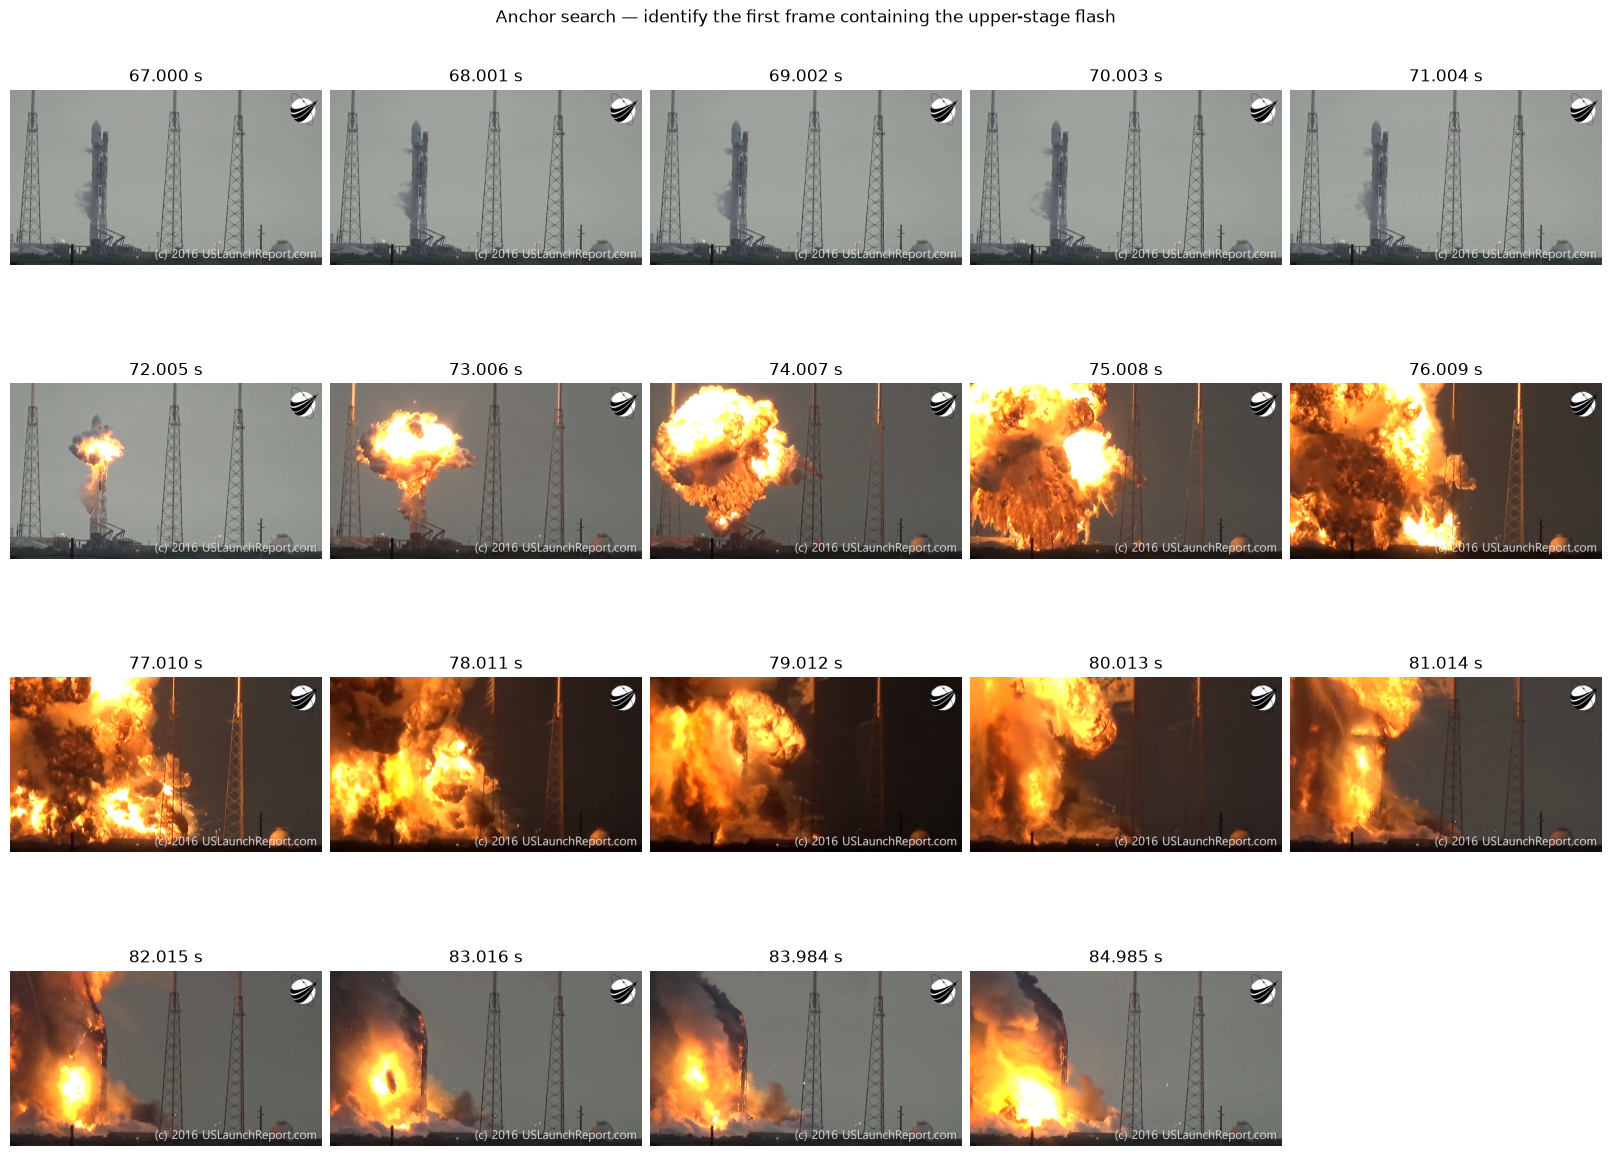

Set VIDEO_ANCHOR_S approximately to the first-flash neighborhood found above, rerun the configuration and video-reader cells, then run the fine preview below.


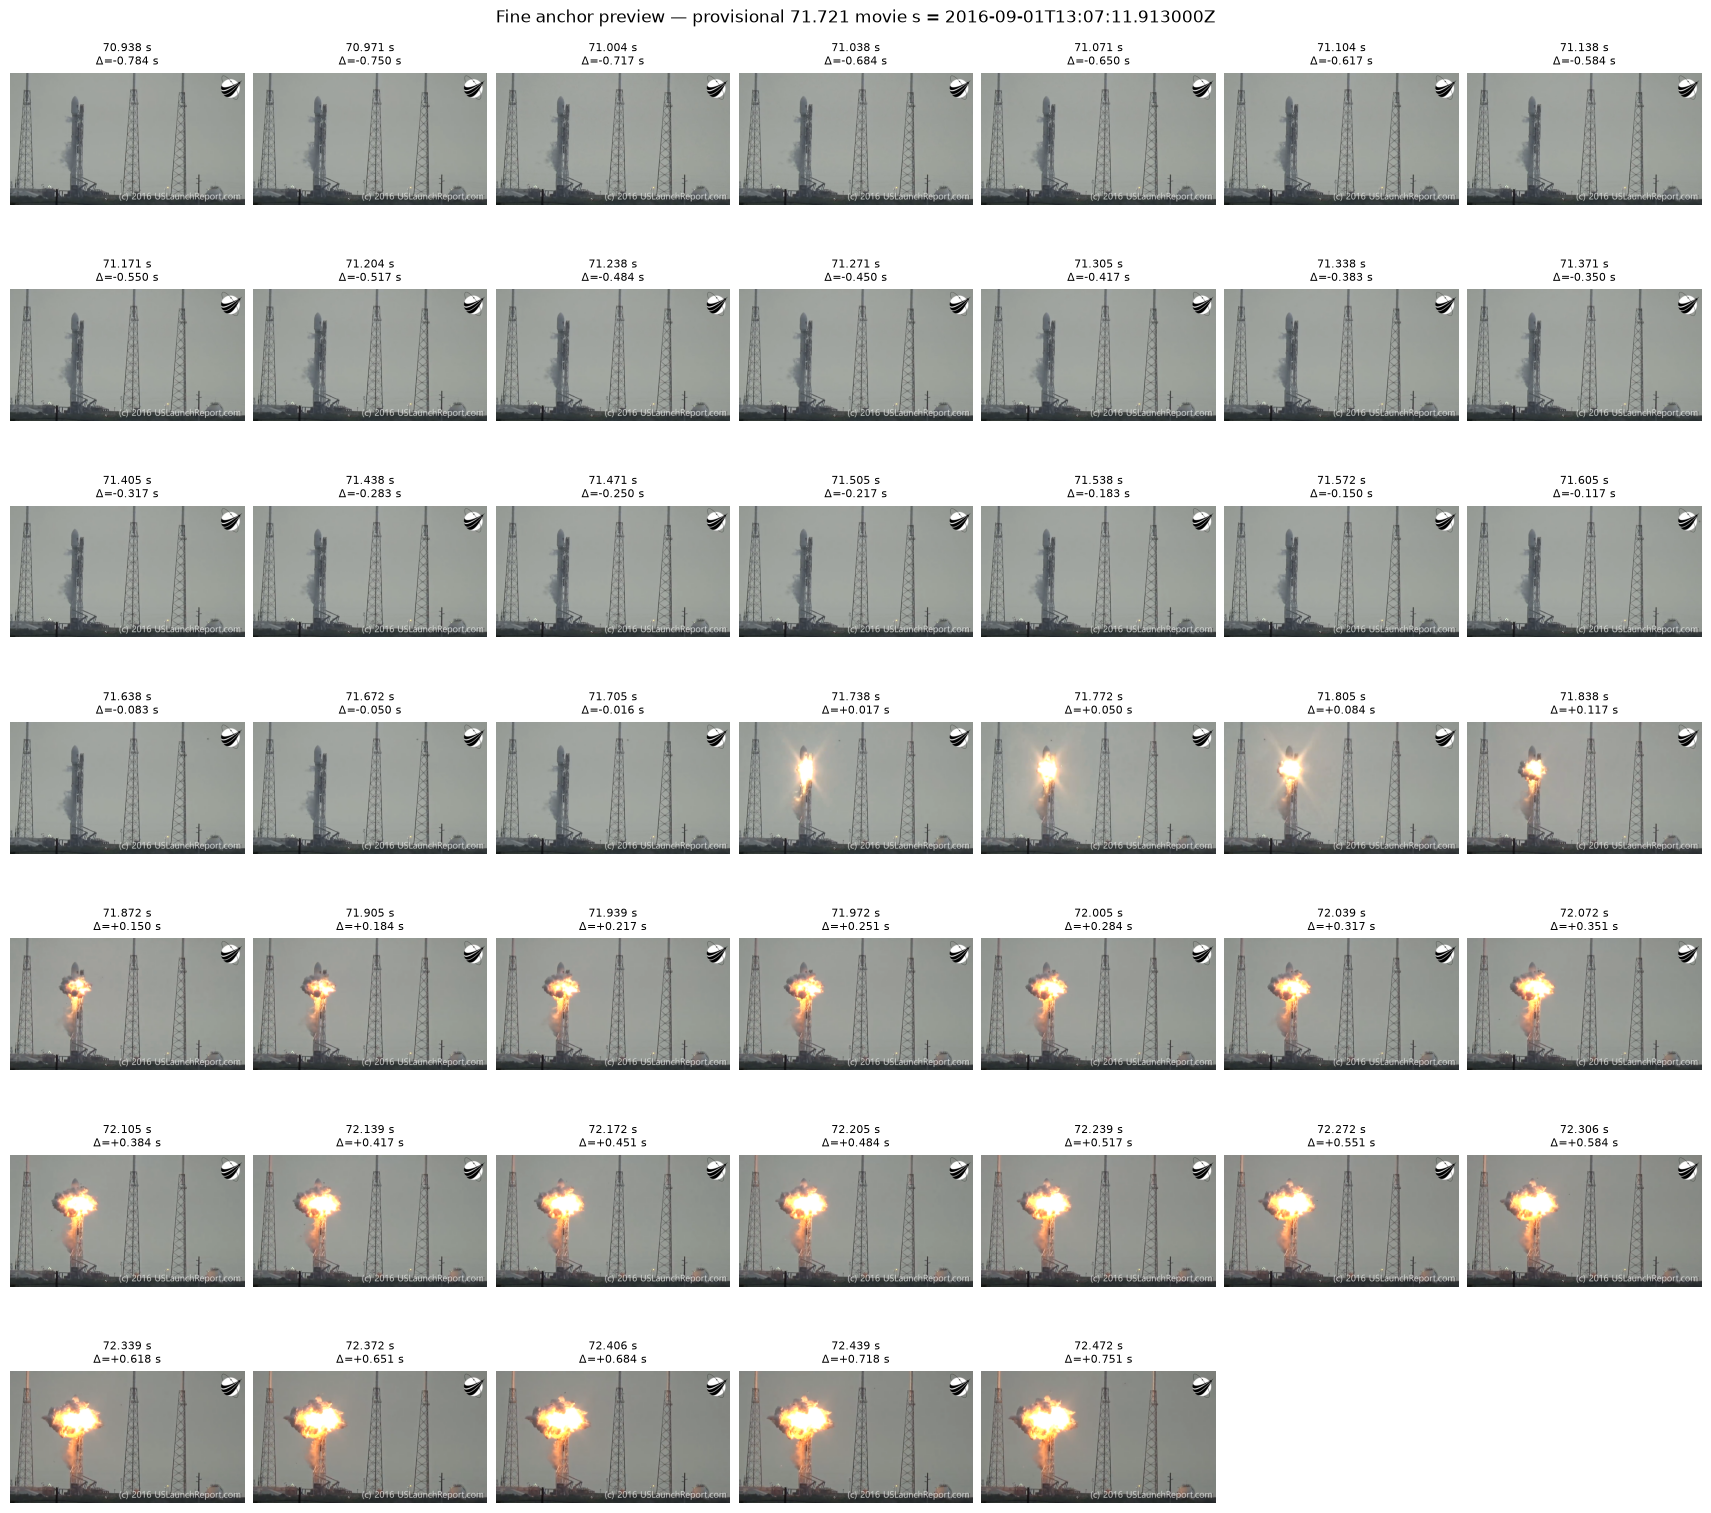

Anchor preview: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/video_sync_anchor_preview.pdf
Choose the FIRST frame showing the upper-stage flash. Copy the movie timestamp printed above that frame into VIDEO_ANCHOR_S, set ANCHOR_IS_CONFIRMED=True, and rerun from the configuration cell.


In [5]:
# -------------------------------------------------------------------------
# Video-anchor calibration
# -------------------------------------------------------------------------
# Stage 1: one-second sampling over the explosion neighborhood established by
# the coarse whole-video contact sheet.
search_times_s = np.arange(
    ANCHOR_SEARCH_START_S,
    ANCHOR_SEARCH_END_S + 0.5 * ANCHOR_SEARCH_STEP_S,
    ANCHOR_SEARCH_STEP_S,
)

ncols = 5
nrows = int(np.ceil(len(search_times_s) / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 3.0 * nrows),
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, requested_s in zip(axes, search_times_s):
    frame, actual_s = video_reader.frame_at_video_seconds(float(requested_s))
    if frame is None:
        ax.text(0.5, 0.5, "No frame", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.imshow(frame)
    ax.set_axis_off()
    ax.set_title(f"{actual_s:.3f} s")

for ax in axes[len(search_times_s):]:
    ax.set_visible(False)

fig.suptitle(
    "Anchor search — identify the first frame containing the upper-stage flash"
)
plt.show()
plt.close(fig)

print(
    "Set VIDEO_ANCHOR_S approximately to the first-flash neighborhood found "
    "above, rerun the configuration and video-reader cells, then run the fine "
    "preview below."
)

# Stage 2: source-frame spacing around the configured anchor.
source_fps = (
    video_reader.nominal_fps
    if np.isfinite(video_reader.nominal_fps)
    else RENDER_FPS
)
fine_frame_count = int(np.ceil(FINE_ANCHOR_HALF_WIDTH_S * source_fps))
fine_offsets_s = (
    np.arange(-fine_frame_count, fine_frame_count + 1, dtype=float)
    / source_fps
)

ncols = 7
nrows = int(np.ceil(len(fine_offsets_s) / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(17, 2.2 * nrows),
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, offset_s in zip(axes, fine_offsets_s):
    requested_s = VIDEO_ANCHOR_S + float(offset_s)
    frame, actual_s = video_reader.frame_at_video_seconds(requested_s)
    if frame is None:
        ax.text(0.5, 0.5, "No frame", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.imshow(frame)
    ax.set_axis_off()
    ax.set_title(
        f"{actual_s:.3f} s\n"
        f"Δ={actual_s - VIDEO_ANCHOR_S:+.3f} s",
        fontsize=8,
    )

for ax in axes[len(fine_offsets_s):]:
    ax.set_visible(False)

fig.suptitle(
    f"Fine anchor preview — provisional {VIDEO_ANCHOR_S:.3f} movie s "
    f"= {VIDEO_ANCHOR_UTC}"
)
fig.savefig(CALIBRATION_FIGURE, dpi=140, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Anchor preview:", CALIBRATION_FIGURE)
print(
    "Choose the FIRST frame showing the upper-stage flash. Copy the movie "
    "timestamp printed above that frame into VIDEO_ANCHOR_S, set "
    "ANCHOR_IS_CONFIRMED=True, and rerun from the configuration cell."
)


## 6. Rendering helpers


In [6]:
def plot_normalized_stream(
    ax, stream, reference_utc, scales, *, receiver_kind: str, offsets=True
):
    traces = list(stream)
    spacing = 2.2 if offsets else 0.0
    y_positions = {}
    for index, trace in enumerate(traces):
        times = (
            relative_time(trace, reference_utc)
            - receiver_time_shift_s(receiver_kind, trace)
        )
        values = np.asarray(trace.data, dtype=float) / scales[trace.id]
        offset = index * spacing
        ax.plot(times, values + offset, lw=0.65, color="black", label=trace.stats.channel)
        y_positions[trace.id] = offset
    if offsets:
        ax.set_yticks([index * spacing for index in range(len(traces))])
        ax.set_yticklabels([trace.stats.channel for trace in traces])
    return spacing, y_positions


def static_marker_display_x(marker: dict, receiver_kind: str) -> float | None:
    '''Return one named-event marker in the panel's displayed time basis.'''
    source_delay_s = float(marker["source_delay_s"])
    marker_kind = marker["marker_kind"]

    if marker_kind == "source":
        return source_delay_s

    if marker_kind == "candidate_p":
        if receiver_kind not in {"seismic", "polarization"}:
            return None
        observed_x = source_delay_s + CANDIDATE_P_DELAY_S
        if ALIGNMENT_MODE == "observed_utc":
            return observed_x
        return observed_x - receiver_time_shift_s(receiver_kind)

    if marker_kind == "airwave":
        if receiver_kind == "camera_audio":
            observed_x = source_delay_s + YOUTUBE_CAMERA_TRAVEL_TIME_S
            shift_s = YOUTUBE_CAMERA_TRAVEL_TIME_S
        elif receiver_kind in {"infrasound", "seismic", "polarization"}:
            travel_s = (seismic_reference_distance_m / SOUND_SPEED_MPS
                        if receiver_kind in {"seismic", "polarization"}
                        else infra_reference_delay_s)
            observed_x = source_delay_s + travel_s
            shift_s = receiver_time_shift_s(receiver_kind)
        else:
            return None
        return observed_x if ALIGNMENT_MODE == "observed_utc" else observed_x - shift_s

    raise ValueError(f"Unknown marker kind: {marker_kind}")


def add_reference_markers(ax, receiver_kind: str):
    '''Add named source, airwave, and provisional P guides.'''
    if not SHOW_STATIC_EVENT_MARKERS:
        return
    for marker in REFERENCE_MARKERS:
        x = static_marker_display_x(marker, receiver_kind)
        if x is None:
            continue
        marker_kind = marker["marker_kind"]
        if marker_kind == "source":
            color, linestyle, alpha = "0.05", ":", 0.75
            suffix = "source"
        elif marker_kind == "candidate_p":
            color, linestyle, alpha = "0.35", "-.", 0.60
            suffix = "exploratory pre-airwave onset"
        else:
            color, linestyle, alpha = "0.65", "--", 0.52
            suffix = "airwave"
        ax.axvline(
            float(x),
            color=color,
            ls=linestyle,
            lw=0.75,
            alpha=alpha,
            label=f"{marker['event_label']} {suffix}",
            zorder=1,
        )


def add_current_video_utc_cursor(ax, elapsed_s: float):
    '''Mark the mapped source time represented by the current video frame.'''
    if SHOW_CURRENT_VIDEO_UTC_CURSOR:
        ax.axvline(
            elapsed_s,
            color="0.05",
            lw=1.5,
            alpha=0.95,
            zorder=8,
        )


def add_camera_acoustic_cursor(ax, elapsed_s: float):
    '''Mark when the currently visible source reaches the camera microphone.'''
    if not SHOW_CAMERA_ACOUSTIC_CURSOR:
        return
    x = (
        elapsed_s
        if ALIGNMENT_MODE == "source_aligned"
        else elapsed_s + YOUTUBE_CAMERA_TRAVEL_TIME_S
    )
    ax.axvline(
        x,
        color="0.35",
        lw=2.0,
        alpha=0.95,
        zorder=9,
        label=(
            "Current-frame camera audio (source-aligned)"
            if ALIGNMENT_MODE == "source_aligned"
            else "Current-frame predicted camera arrival"
        ),
    )


def add_dynamic_trace_arrivals(
    ax,
    stream,
    y_positions,
    elapsed_s: float,
    propagation_speed_mps: float,
    distances_m: dict[str, float],
    *,
    display_shift_speed_mps: float | None,
    color: str,
    label: str,
    marker_half_height: float = 0.65,
):
    '''Mark receiver arrivals of the disturbance visible in the current frame.'''
    arrival_x = []
    for trace in stream:
        distance_m = float(distances_m[trace.id])
        physical_travel_s = distance_m / float(propagation_speed_mps)
        x = elapsed_s + physical_travel_s
        if ALIGNMENT_MODE == "source_aligned":
            if display_shift_speed_mps is None:
                raise ValueError(
                    "source_aligned arrivals require display_shift_speed_mps"
                )
            x -= distance_m / float(display_shift_speed_mps)
        y = float(y_positions[trace.id])
        ax.vlines(
            x,
            y - marker_half_height,
            y + marker_half_height,
            color=color,
            lw=2.0,
            alpha=0.95,
            zorder=9,
        )
        arrival_x.append(x)

    if arrival_x:
        ax.plot([], [], color=color, lw=2.0, label=label)
    return arrival_x


def render_sync_frame(render_utc: UTCDateTime, output_path: Path):
    elapsed_s = float(render_utc - VIDEO_ANCHOR_UTC)
    frame_rgb, actual_video_s = video_reader.frame_at_utc(render_utc)

    show_audio = (
        SHOW_VIDEO_AUDIO_PANEL
        and audio_time_s is not None
        and audio_values is not None
    )
    nrows = 6 if show_audio else 5
    height_ratios = (
        [3.2, 0.9, 1.35, 1.35, 1.35, 1.25]
        if show_audio
        else [3.2, 1.35, 1.35, 1.35, 1.25]
    )

    fig = plt.figure(figsize=(14, 11 if show_audio else 10))
    grid = GridSpec(nrows, 1, figure=fig, height_ratios=height_ratios)
    fig.subplots_adjust(
        left=0.08, right=0.98, bottom=0.055, top=0.94, hspace=0.42
    )

    row = 0
    ax_video = fig.add_subplot(grid[row, 0])
    row += 1
    if frame_rgb is None:
        ax_video.text(
            0.5, 0.5, "No video frame at this mapped time",
            ha="center", va="center", transform=ax_video.transAxes,
        )
    else:
        ax_video.imshow(frame_rgb)
    ax_video.set_axis_off()
    ax_video.set_title(
        "SpaceXStaticFireAnomalyAMOS_6_Youtube.mov — "
        f"video PTS {actual_video_s:.3f} s — "
        "mapped source UTC "
        f"{render_utc.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}"
    )

    if show_audio:
        ax_audio = fig.add_subplot(grid[row, 0])
        row += 1
        ax_audio.plot(audio_time_s, audio_values, color="black", lw=0.45)
        add_current_video_utc_cursor(ax_audio, elapsed_s)
        add_camera_acoustic_cursor(ax_audio, elapsed_s)
        add_reference_markers(ax_audio, "camera_audio")
        if AUDIO_PANEL_ZOOMED:
            ax_audio.set_xlim(
                elapsed_s - WAVEFORM_ZOOM_S / 2,
                elapsed_s + WAVEFORM_ZOOM_S / 2,
            )
        else:
            ax_audio.set_xlim(
                float(RENDER_START_UTC - VIDEO_ANCHOR_UTC),
                float(RENDER_END_UTC - VIDEO_ANCHOR_UTC),
            )
        ax_audio.set_ylim(-1.05, 1.05)
        ax_audio.set_ylabel("Camera audio\n>300 Hz")
        ax_audio.grid(True, alpha=0.15)

    ax_infra = fig.add_subplot(grid[row, 0])
    row += 1
    _, infra_y = plot_normalized_stream(
        ax_infra, st_infrasound_plot, VIDEO_ANCHOR_UTC, infra_scales,
        receiver_kind="infrasound", offsets=True,
    )
    add_current_video_utc_cursor(ax_infra, elapsed_s)
    add_reference_markers(ax_infra, "infrasound")

    if SHOW_DYNAMIC_INFRASOUND_ARRIVALS:
        if ALIGNMENT_MODE == "source_aligned":
            band_left = elapsed_s - 0.01
            band_right = elapsed_s + 0.01
        else:
            band_left = elapsed_s + infra_band_distance_min_m / SOUND_SPEED_MPS
            band_right = elapsed_s + infra_band_distance_max_m / SOUND_SPEED_MPS
        ax_infra.axvspan(
            band_left,
            band_right,
            color="0.82",
            alpha=0.35,
            zorder=2,
            label="Current-frame acoustic arrival across array",
        )
        add_dynamic_trace_arrivals(
            ax_infra,
            st_infrasound_plot,
            infra_y,
            elapsed_s,
            SOUND_SPEED_MPS,
            infra_distances_m,
            display_shift_speed_mps=SOUND_SPEED_MPS,
            color="0.30",
            label="Per-channel acoustic arrival",
        )

    ax_infra.set_xlim(
        float(RENDER_START_UTC - VIDEO_ANCHOR_UTC),
        float(RENDER_END_UTC - VIDEO_ANCHOR_UTC),
    )
    ax_infra.set_ylabel("Infrasound\n(normalized)")
    ax_infra.grid(True, alpha=0.15)

    ax_seis_full = fig.add_subplot(grid[row, 0])
    row += 1
    _, seis_full_y = plot_normalized_stream(
        ax_seis_full, st_seismic_plot, VIDEO_ANCHOR_UTC, seismic_scales,
        receiver_kind="seismic", offsets=True,
    )
    add_current_video_utc_cursor(ax_seis_full, elapsed_s)
    add_reference_markers(ax_seis_full, "seismic")
    if SHOW_DYNAMIC_P_ARRIVALS:
        add_dynamic_trace_arrivals(
            ax_seis_full,
            st_seismic_plot,
            seis_full_y,
            elapsed_s,
            P_WAVE_SPEED_MPS,
            seismic_distances_m,
            display_shift_speed_mps=SOUND_SPEED_MPS,
            color="0.40",
            label="Current-frame exploratory pre-airwave arrival",
        )
    ax_seis_full.set_xlim(
        float(RENDER_START_UTC - VIDEO_ANCHOR_UTC),
        float(RENDER_END_UTC - VIDEO_ANCHOR_UTC),
    )
    ax_seis_full.set_ylabel("Z/R/T\n(acoustic-reduced)" if ALIGNMENT_MODE == "source_aligned" else "Z/R/T\n(observed)")
    ax_seis_full.grid(True, alpha=0.15)

    ax_seis_zoom = fig.add_subplot(grid[row, 0])
    row += 1
    _, seis_zoom_y = plot_normalized_stream(
        ax_seis_zoom, st_seismic_plot, VIDEO_ANCHOR_UTC, seismic_scales,
        receiver_kind="seismic", offsets=True,
    )
    add_current_video_utc_cursor(ax_seis_zoom, elapsed_s)
    if SHOW_DYNAMIC_P_ARRIVALS:
        add_dynamic_trace_arrivals(
            ax_seis_zoom,
            st_seismic_plot,
            seis_zoom_y,
            elapsed_s,
            P_WAVE_SPEED_MPS,
            seismic_distances_m,
            display_shift_speed_mps=SOUND_SPEED_MPS,
            color="0.40",
            label="Current-frame exploratory pre-airwave arrival",
        )
    ax_seis_zoom.set_xlim(
        elapsed_s - WAVEFORM_ZOOM_S / 2,
        elapsed_s + WAVEFORM_ZOOM_S / 2,
    )
    ax_seis_zoom.set_ylabel("Scrolling\nZ/R/T")
    ax_seis_zoom.grid(True, alpha=0.15)

    ax_pol = fig.add_subplot(grid[row, 0])
    pol_left = elapsed_s - WAVEFORM_ZOOM_S / 2
    pol_right = elapsed_s + WAVEFORM_ZOOM_S / 2
    polarization_shift_s = receiver_time_shift_s("polarization")
    polarization_display_time_s = (
        polarization["elapsed_from_upper_stage_s"] - polarization_shift_s
    )
    pol_visible = polarization.loc[
        (polarization_display_time_s >= pol_left - 1.0)
        & (polarization_display_time_s <= pol_right + 1.0)
    ].copy()
    pol_visible["display_time_s"] = (
        pol_visible["elapsed_from_upper_stage_s"] - polarization_shift_s
    )
    plotted_pol_series = 0
    grayscale = np.linspace(0.05, 0.70, len(POLARIZATION_ATTRIBUTES))
    for (column, label), gray in zip(POLARIZATION_ATTRIBUTES, grayscale):
        if column not in pol_visible.columns:
            continue
        finite = np.isfinite(pol_visible[column].to_numpy(dtype=float))
        if not finite.any():
            continue
        ax_pol.plot(
            pol_visible.loc[finite, "display_time_s"],
            pol_visible.loc[finite, column],
            lw=1.0,
            color=str(gray),
            label=label,
        )
        plotted_pol_series += 1
    add_current_video_utc_cursor(ax_pol, elapsed_s)
    add_reference_markers(ax_pol, "polarization")
    ax_pol.set_xlim(pol_left, pol_right)
    ax_pol.set_ylim(-0.05, 1.05)
    ax_pol.set_ylabel("Polarization")
    ax_pol.set_xlabel(
        "Acoustic-reduced time relative to upper-stage source (s)"
        if ALIGNMENT_MODE == "source_aligned"
        else "Observed UTC relative to upper-stage source (s)"
    )
    if plotted_pol_series:
        ax_pol.legend(loc="upper right", ncol=min(5, plotted_pol_series), fontsize=7)
    else:
        ax_pol.text(
            0.5, 0.5,
            "No finite polarization values in this window",
            ha="center", va="center", transform=ax_pol.transAxes,
        )
    ax_pol.grid(True, alpha=0.15)

    for ax in ([ax_audio] if show_audio else []) + [ax_infra, ax_seis_full, ax_seis_zoom]:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            dedup = dict(zip(labels, handles))
            ax.legend(
                dedup.values(), dedup.keys(),
                loc="upper right", fontsize=6,
                ncol=min(4, len(dedup)),
            )

    fig.suptitle(
        "Falcon 9 AMOS-6 anomaly — "
        f"{ALIGNMENT_MODE.replace('_', ' ')} — "
        "mapped source UTC "
        f"{render_utc.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}"
    )
    fig.savefig(output_path, dpi=FIGURE_DPI, facecolor="white")
    plt.close(fig)


## 7. Render synchronized PNG frames

Rendering is restartable. Existing non-empty `frame_*.png` files are reused whenever
`DELETE_EXISTING_FRAMES=False`; a manifest difference now produces a warning rather
than deleting work. Frames are rendered in small batches, with the video reader
reopened and garbage collected between batches to avoid progressive slowdown in
long runs.


In [7]:
# Rendering is performed by the resumable, configuration-aware cell below.


In [8]:
import gc
import time

render_duration_s = float(RENDER_END_UTC - RENDER_START_UTC)
number_of_frames = EXPECTED_FRAME_COUNT

# Keep this manifest deliberately stable. Do not derive it from every live
# Python function in globals(): that made harmless notebook/session differences
# look like render changes and caused DELETE_EXISTING_FRAMES=False to be ignored.
render_configuration = {
    "render_schema_version": int(RENDER_SCHEMA_VERSION),
    "input_fingerprints": {
        str(path): file_fingerprint(path)
        for path in (
            VIDEO_FILE,
            BASELINE_STREAM_FILE,
            ROTATED_ZRT_PICKLE,
            POLARIZATION_CSV,
            WEATHER_SUMMARY_FILE,
            ANALYSIS_CONFIG_FILE,
            config.KML_FILE,
        )
    },
    "source_events": [
        (key, label, str(time))
        for key, label, time in NAMED_SOURCE_EVENTS
    ],
    "residual_shift_s": config.REDUCED_TIME_RESIDUAL_SHIFT_S,
    "figure_dpi": FIGURE_DPI,
    "waveform_zoom_s": WAVEFORM_ZOOM_S,
    "display_flags": {
        key: value
        for key, value in globals().copy().items()
        if key.startswith("SHOW_") and isinstance(value, bool)
    },
    "alignment_mode": ALIGNMENT_MODE,
    "video_file": str(VIDEO_FILE),
    "video_anchor_movie_s": VIDEO_ANCHOR_S,
    "video_anchor_utc": str(VIDEO_ANCHOR_UTC),
    "render_start_utc": str(RENDER_START_UTC),
    "render_end_utc": str(RENDER_END_UTC),
    "render_fps": RENDER_FPS,
    "expected_frame_count": number_of_frames,
    "bchh_effective_sound_speed_mps": SOUND_SPEED_MPS,
    "camera_effective_sound_speed_mps": YOUTUBE_CAMERA_EFFECTIVE_SPEED_MPS,
    "camera_travel_time_s": YOUTUBE_CAMERA_TRAVEL_TIME_S,
    "exploratory_pre_airwave_apparent_speed_mps": P_WAVE_SPEED_MPS,
    "seismic_filter_hz": list(SEISMIC_FILTER_HZ),
    "infrasound_filter_hz": list(INFRASOUND_FILTER_HZ),
    "audio_panel_highpass_hz": AUDIO_PANEL_HIGHPASS_HZ,
}

previous_render_configuration = None
if FRAME_MANIFEST_JSON.exists():
    try:
        previous_render_configuration = json.loads(
            FRAME_MANIFEST_JSON.read_text()
        )
    except Exception as exc:
        print(
            "Warning: could not read previous frame manifest; "
            f"existing PNGs will still be preserved ({exc})."
        )

configuration_changed = (
    previous_render_configuration is not None
    and previous_render_configuration != render_configuration
)

# This flag now means exactly what it says.
if DELETE_EXISTING_FRAMES:
    existing = list(FRAME_DIR.glob("frame_*.png"))
    for path in existing:
        path.unlink()
    if existing:
        print(
            f"Removed {len(existing)} generated frames because "
            "DELETE_EXISTING_FRAMES=True"
        )
elif configuration_changed:
    existing_count = len(list(FRAME_DIR.glob("frame_*.png")))
    print(
        "WARNING: render configuration differs from the previous manifest, "
        f"but DELETE_EXISTING_FRAMES=False, so {existing_count} existing "
        "frames are being preserved and may be reused."
    )
    print(
        "If this was an intentional appearance/timing change, set "
        "DELETE_EXISTING_FRAMES=True once, rerun this cell, then set it "
        "back to False."
    )

FRAME_MANIFEST_JSON.write_text(
    json.dumps(render_configuration, indent=2) + "\n"
)

def _valid_existing_frame(path: Path) -> bool:
    """Cheap resume check: frame exists and is non-empty."""
    try:
        return path.is_file() and path.stat().st_size > 0
    except OSError:
        return False


existing_frame_numbers = {
    int(path.stem.split("_")[-1])
    for path in FRAME_DIR.glob("frame_*.png")
    if (
        path.stem.split("_")[-1].isdigit()
        and _valid_existing_frame(path)
    )
}

missing_frame_numbers = [
    frame_number
    for frame_number in range(number_of_frames)
    if frame_number not in existing_frame_numbers
]

print(
    f"Requested frames: {number_of_frames}; "
    f"reusable frames: {len(existing_frame_numbers)}; "
    f"missing frames: {len(missing_frame_numbers)}"
)

if existing_frame_numbers:
    first_missing = (
        missing_frame_numbers[0]
        if missing_frame_numbers
        else None
    )
    print(
        "Resume status: "
        f"highest existing frame={max(existing_frame_numbers):06d}; "
        f"first missing={first_missing if first_missing is not None else 'none'}"
    )

render_start_clock = time.perf_counter()
frames_rendered_this_run = 0

if RENDER_PNG_FRAMES and missing_frame_numbers:
    batch_size = max(1, int(RENDER_BATCH_SIZE))

    for batch_start in range(0, len(missing_frame_numbers), batch_size):
        batch = missing_frame_numbers[
            batch_start:batch_start + batch_size
        ]

        # Reopen PyAV between batches. Long-lived seek/decode state was a likely
        # contributor to progressive slowdown and kernel instability.
        if (
            batch_start > 0
            and REOPEN_VIDEO_READER_BETWEEN_BATCHES
        ):
            try:
                video_reader.close()
            except Exception:
                pass
            video_reader = UTCVideoReader(VIDEO_FILE, video_start_utc)

        print(
            f"Rendering batch "
            f"{batch_start // batch_size + 1}/"
            f"{int(np.ceil(len(missing_frame_numbers) / batch_size))}: "
            f"frames {batch[0]}–{batch[-1]}",
            flush=True,
        )

        batch_clock = time.perf_counter()

        for frame_number in batch:
            output_path = FRAME_DIR / f"frame_{frame_number:06d}.png"

            # Recheck immediately before rendering, making restart/resume safe
            # even if the directory changed after the initial scan.
            if _valid_existing_frame(output_path):
                continue

            render_utc = (
                RENDER_START_UTC
                + frame_number / RENDER_FPS
            )
            frame_clock = time.perf_counter()

            render_sync_frame(render_utc, output_path)

            frame_seconds = time.perf_counter() - frame_clock
            frames_rendered_this_run += 1

            if (
                frames_rendered_this_run == 1
                or frames_rendered_this_run % 10 == 0
                or frame_number == missing_frame_numbers[-1]
            ):
                elapsed = (
                    time.perf_counter() - render_start_clock
                )
                mean_seconds = (
                    elapsed / frames_rendered_this_run
                )
                frames_left = (
                    len(missing_frame_numbers)
                    - frames_rendered_this_run
                )

                print(
                    f"Rendered frame {frame_number + 1}/"
                    f"{number_of_frames}: "
                    f"{output_path.name}; "
                    f"this={frame_seconds:.2f} s; "
                    f"mean(new)={mean_seconds:.2f} s/frame; "
                    f"estimated remaining="
                    f"{frames_left * mean_seconds / 60:.1f} min",
                    flush=True,
                )

        batch_seconds = time.perf_counter() - batch_clock
        print(
            f"Batch complete in {batch_seconds:.1f} s; "
            f"frames now present="
            f"{len(list(FRAME_DIR.glob('frame_*.png')))}",
            flush=True,
        )

        # Be aggressive about releasing plotting/decoder garbage before
        # continuing. render_sync_frame already closes its figure.
        plt.close("all")
        gc.collect()

elif RENDER_PNG_FRAMES:
    print("All expected frames already exist; nothing to render.")
else:
    print(
        "RENDER_PNG_FRAMES is False; "
        "no production frames rendered."
    )

rendered_frames = sorted(FRAME_DIR.glob("frame_*.png"))
print("Frames present:", len(rendered_frames))


If this was an intentional appearance/timing change, set DELETE_EXISTING_FRAMES=True once, rerun this cell, then set it back to False.
Requested frames: 616; reusable frames: 377; missing frames: 239
Resume status: highest existing frame=000376; first missing=377
Rendering batch 1/6: frames 377–416
Rendered frame 378/616: frame_000377.png; this=0.30 s; mean(new)=0.30 s/frame; estimated remaining=1.2 min
Rendered frame 387/616: frame_000386.png; this=0.30 s; mean(new)=0.31 s/frame; estimated remaining=1.2 min
Rendered frame 397/616: frame_000396.png; this=0.38 s; mean(new)=0.31 s/frame; estimated remaining=1.1 min
Rendered frame 407/616: frame_000406.png; this=0.30 s; mean(new)=0.31 s/frame; estimated remaining=1.1 min
Rendered frame 417/616: frame_000416.png; this=0.30 s; mean(new)=0.31 s/frame; estimated remaining=1.0 min
Batch complete in 12.4 s; frames now present=417
Rendering batch 2/6: frames 417–456
Rendered frame 427/616: frame_000426.png; this=0.31 s; mean(new)=0.31 s/frame; e

## 8. Assemble the MP4 with ffmpeg


In [11]:
import subprocess
from PIL import Image

def assemble_sync_movie():

    rendered_frames = sorted(FRAME_DIR.glob("frame_*.png"))
    if not rendered_frames:
        raise FileNotFoundError(f"No PNG frames found in {FRAME_DIR}")

    expected_names = [
        FRAME_DIR / f"frame_{index:06d}.png"
        for index in range(EXPECTED_FRAME_COUNT)
    ]
    missing_frames = [path for path in expected_names if not path.exists()]
    if missing_frames:
        raise RuntimeError(
            f"Cannot assemble movie: {len(missing_frames)} expected PNG frames "
            f"are missing. First missing: {missing_frames[0]}"
        )

    with Image.open(rendered_frames[0]) as image:
        frame_width, frame_height = image.size

    print(
        f"Found {len(rendered_frames)} frames; "
        f"frame dimensions={frame_width} × {frame_height}"
    )
    print(
        "PNG frame 000000 source PTS:",
        f"{FIRST_RENDERED_VIDEO_PTS_S:.6f} s",
    )

    ffmpeg_path = shutil.which("ffmpeg")
    if ASSEMBLE_MP4:
        if ffmpeg_path is None:
            raise FileNotFoundError("ffmpeg was not found on PATH.")

        use_source_audio = (
            INCLUDE_VIDEO_AUDIO_IN_MP4
            and video_reader.has_audio
            and EXTRACTED_AUDIO_WAV.exists()
            and EXTRACTED_AUDIO_WAV.stat().st_size > 0
        )

        command = [
            ffmpeg_path,
            "-y",
            "-framerate", f"{RENDER_FPS:.8f}",
            "-i", str(FRAME_DIR / "frame_%06d.png"),
        ]

        if use_source_audio:
            # This WAV was clipped once using the actual PTS of PNG frame 000000.
            # It already starts at zero, so no second seek/trim is allowed here.
            command += [
                "-i", str(EXTRACTED_AUDIO_WAV),
            ]

        command += [
            "-map", "0:v:0",
        ]
        if use_source_audio:
            command += ["-map", "1:a:0"]

        command += [
            "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
            "-c:v", "libx264",
            "-preset", "medium",
            "-crf", "18",
            "-pix_fmt", "yuv420p",
            "-r", f"{RENDER_FPS:.8f}",
        ]

        if use_source_audio:
            command += [
                "-c:a", "aac",
                "-b:a", "192k",
            ]

        command += [
            "-t", f"{PNG_SEQUENCE_DURATION_S:.9f}",
            "-movflags", "+faststart",
            str(OUTPUT_MOVIE),
        ]

        print("Running:")
        print(" ".join(command))

        result = subprocess.run(
            command,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
        )

        if result.returncode != 0:
            diagnostic_tail = "\n".join(result.stderr.splitlines()[-60:])
            raise RuntimeError(
                f"FFmpeg failed with return code {result.returncode}.\n\n"
                f"{diagnostic_tail}"
            )

        if not OUTPUT_MOVIE.exists() or OUTPUT_MOVIE.stat().st_size < 1:
            diagnostic_tail = "\n".join(result.stderr.splitlines()[-60:])
            output_bytes = (
                OUTPUT_MOVIE.stat().st_size if OUTPUT_MOVIE.exists() else 0
            )
            raise RuntimeError(
                f"Output movie is missing or unexpectedly small "
                f"({output_bytes:,} bytes).\n\n"
                f"{diagnostic_tail}"
            )

        print(f"Created: {OUTPUT_MOVIE}")
        print(
            f"Size: {OUTPUT_MOVIE.stat().st_size / 1024**2:.3f} MB "
            f"({OUTPUT_MOVIE.stat().st_size:,} bytes)"
        )
        print("Source audio included:", use_source_audio)
        if use_source_audio:
            print(
                "Audio extraction source PTS:",
                f"{AUDIO_EXTRACTION_START_PTS_S:.6f} s",
            )
            print(
                "Audio advanced relative to video by:",
                f"{AUDIO_SOURCE_ADVANCE_S:.3f} s",
            )
    else:
        print("ASSEMBLE_MP4 is False; PNG frames retained without movie assembly.")
if ASSEMBLE_MP4:
    assemble_sync_movie()
else:
    print("ASSEMBLE_MP4 is False; no frame checks or assembly requested.")


Found 616 frames; frame dimensions=1400 × 1100
PNG frame 000000 source PTS: 69.736333 s
Running:
/opt/anaconda3/envs/flovopy_plus/bin/ffmpeg -y -framerate 29.97002997 -i /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/frames_phase1_source_aligned/frame_%06d.png -i /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/youtube_audio_source_aligned.wav -map 0:v:0 -map 1:a:0 -vf pad=ceil(iw/2)*2:ceil(ih/2)*2 -c:v libx264 -preset medium -crf 18 -pix_fmt yuv420p -r 29.97002997 -c:a aac -b:a 192k -t 20.553866667 -movflags +faststart /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/youtube_waveform_polarization_source_aligned.mp4
Created: /Users/glennthompson

## 9. Save synchronization provenance and close the video


In [12]:
sync_configuration = {
    "requested_render_start_utc": str(REQUESTED_RENDER_START_UTC),
    "render_configuration": render_configuration,
    "anchor_status": "configured_constructed_alignment; no independent video UTC",
    "producer_notebook": "160_generate_synchronized_phase1_video.ipynb",
    "video_file": str(VIDEO_FILE),
    "video_has_no_independent_absolute_clock": True,
    "video_anchor_s": VIDEO_ANCHOR_S,
    "video_anchor_utc": str(VIDEO_ANCHOR_UTC),
    "video_anchor_interpretation": (
        "movie first upper-stage flash mapped to the infrasound-derived "
        "upper-stage source time"
    ),
    "video_pick_uncertainty_s": config.VIDEO_PICK_UNCERTAINTY_S,
    "reduced_time_residual_shift_s": config.REDUCED_TIME_RESIDUAL_SHIFT_S,
    "timing_configuration_source": str(config.__file__),
    "source_event_times_utc": {
        key: str(source_time)
        for key, _, source_time in NAMED_SOURCE_EVENTS
    },
    "alignment_mode": ALIGNMENT_MODE,
    "source_aligned_seismic_basis": (
        "acoustic travel time removed; exploratory pre-airwave markers disabled"
    ),
    "derived_video_start_utc": str(video_start_utc),
    "video_nominal_fps": video_reader.nominal_fps,
    "video_duration_s": video_reader.duration_s,
    "video_has_audio": video_reader.has_audio,
    "render_start_utc": str(RENDER_START_UTC),
    "render_end_utc": str(RENDER_END_UTC),
    "render_start_video_s_requested": render_start_video_s,
    "first_rendered_video_pts_s": FIRST_RENDERED_VIDEO_PTS_S,
    "video_start_quantization_offset_s": VIDEO_START_QUANTIZATION_OFFSET_S,
    "png_sequence_duration_s": PNG_SEQUENCE_DURATION_S,
    "render_fps": RENDER_FPS,
    "waveform_zoom_s": WAVEFORM_ZOOM_S,
    "source_waveform_stream": str(BASELINE_STREAM_FILE),
    "source_rotated_zrt_stream": str(ROTATED_ZRT_PICKLE),
    "source_polarization_csv": str(POLARIZATION_CSV),
    "weather_summary": str(WEATHER_SUMMARY_FILE),
    "seismic_filter_hz": list(SEISMIC_FILTER_HZ),
    "infrasound_filter_hz": list(INFRASOUND_FILTER_HZ),
    "bchh_meteorological_effective_sound_speed_mps": SOUND_SPEED_MPS,
    "sound_speed_mps": SOUND_SPEED_MPS,
    "sound_speed_source": "Notebook 020 meteorological effective speed",
    "empirical_array_trace_speed_mps": EMPIRICAL_ARRAY_TRACE_SPEED_MPS,
    "empirical_array_trace_speed_used_for_source_propagation": False,
    "exploratory_pre_airwave_apparent_speed_mps": P_WAVE_SPEED_MPS,
    "exploratory_pre_airwave_onset_delay_s": CANDIDATE_P_DELAY_S,
    "exploratory_pre_airwave_markers_enabled": False,
    "infrasound_reference_delay_s": infra_reference_delay_s,
    "infrasound_array_delay_min_s": infra_band_delay_min_s,
    "infrasound_array_delay_max_s": infra_band_delay_max_s,
    "infrasound_array_delay_spread_s": infra_delay_spread_s,
    "seismic_reference_distance_m": seismic_reference_distance_m,
    "p_reference_delay_s": p_reference_delay_s,
    "infrasound_trace_distances_m": infra_distances_m,
    "seismic_trace_distances_m": seismic_distances_m,
    "trace_geometry": trace_geometry.to_dict(orient="records"),
    "youtube_camera_distance_m": YOUTUBE_CAMERA_DISTANCE_M,
    "youtube_camera_ray_azimuth_deg": YOUTUBE_CAMERA_RAY_AZIMUTH_DEG,
    "youtube_camera_wind_along_ray_mps": YOUTUBE_CAMERA_WIND_ALONG_RAY_MPS,
    "youtube_camera_effective_speed_mps": YOUTUBE_CAMERA_EFFECTIVE_SPEED_MPS,
    "youtube_camera_travel_time_s": YOUTUBE_CAMERA_TRAVEL_TIME_S,
    "youtube_camera_propagation_source": youtube_camera["source"],
    "camera_propagation_audit_csv": str(CAMERA_PROPAGATION_AUDIT_CSV),
    "audio_time_basis": ALIGNMENT_MODE,
    "audio_start_utc": str(RENDER_START_UTC),
    "audio_source_advance_s": AUDIO_SOURCE_ADVANCE_S,
    "audio_extraction_start_pts_s": AUDIO_EXTRACTION_START_PTS_S,
    "audio_panel_highpass_hz": AUDIO_PANEL_HIGHPASS_HZ,
    "include_source_audio_in_mp4": INCLUDE_VIDEO_AUDIO_IN_MP4,
    "show_video_audio_panel": SHOW_VIDEO_AUDIO_PANEL,
    "extracted_audio_wav": str(EXTRACTED_AUDIO_WAV),
    "reference_markers": REFERENCE_MARKERS,
    "frame_directory": str(FRAME_DIR),
    "frame_manifest": str(FRAME_MANIFEST_JSON),
    "output_movie": str(OUTPUT_MOVIE),
    "rendered_frame_count": len(rendered_frames),
}
SYNC_CONFIG_JSON.write_text(json.dumps(sync_configuration, indent=2) + "\n")
video_reader.close()

print("Synchronization configuration:", SYNC_CONFIG_JSON)
print("Anchor preview:", CALIBRATION_FIGURE)
print("Frames:", FRAME_DIR)
print("Movie:", OUTPUT_MOVIE)


Synchronization configuration: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/video_sync_configuration.json
Anchor preview: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/video_sync_anchor_preview.pdf
Frames: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/frames_phase1_source_aligned
Movie: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/youtube_waveform_polarization_source_aligned.mp4
